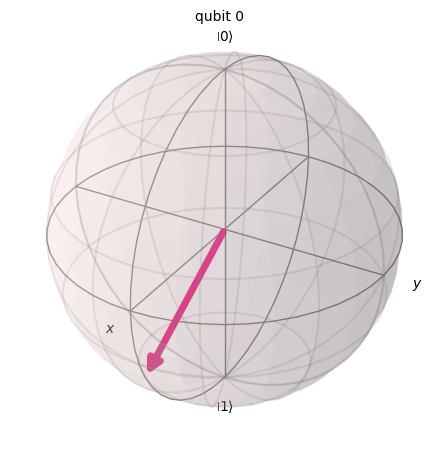

In [21]:
import numpy as np
from qiskit.visualization import plot_bloch_multivector
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector

alpha = 1/2
beta = np.sqrt(3)/2

sv = Statevector([alpha, beta])
plot_bloch_multivector(sv)

In [22]:
# sv = Statevector.from_label("0")

qc1 = QuantumCircuit(1)
qc1.h(0)
sv.data





array([0.5      +0.j, 0.8660254+0.j])

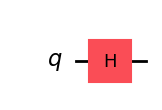

In [23]:
qc1.draw("mpl")


In [24]:
sv = sv.evolve(qc1)
sv.data

array([ 0.96592583+0.j, -0.25881905+0.j])

Subtraction circuit

In [25]:
from qiskit.circuit import (
    QuantumCircuit,
    QuantumRegister,
    AncillaRegister,
    ClassicalRegister,
)
from qiskit.circuit.library import CDKMRippleCarryAdder

In [ ]:
num_state_qubits = 3
adder = CDKMRippleCarryAdder(num_state_qubits, kind='half')
 
subtrahend = QuantumRegister(num_state_qubits, 'A')
minuend = QuantumRegister(num_state_qubits + 1, 'M')
anc = AncillaRegister(adder.num_ancillas, 'anc')
difference = ClassicalRegister(num_state_qubits, 'diff')
 
qc = QuantumCircuit(subtrahend, minuend, anc, difference)
 
# Subtract 11 - 5
#the values start at 0
#each time you "load" a value, you change it it one
#for ex, 11 = 1011 or 2^3 + 2^1 + 2^0 = 8 + 2 + 1 = 11
#so we change the bits in the 0th, 1st, and 3rd position to 1 to represent 11
qc.x([minuend[0], minuend[1], minuend[3]])
#same goes for 5, 5 = 2^2 + 2^0 = 4 + 1 = 5
qc.x([subtrahend[0], subtrahend[2]])
 
qc.append(adder.inverse().to_gate(label=r'  $Adder^\dagger$  '), subtrahend[:] + minuend[:] + anc[:])
qc.measure(minuend[0:num_state_qubits], difference)

result

In [ ]:
from qiskit_aer import Aer
from qiskit import transpile

backend = Aer.get_backend("aer_simulator")

qc = transpile(qc, backend)
qc.save_statevector() 

result = backend.run(qc, shots=1024).result()
counts = result.get_counts()
print(counts)

{'110': 1024}


'110' is representative of 6, the result of the substraction:
2^2 + 2^1 = 4 + 2 = 6

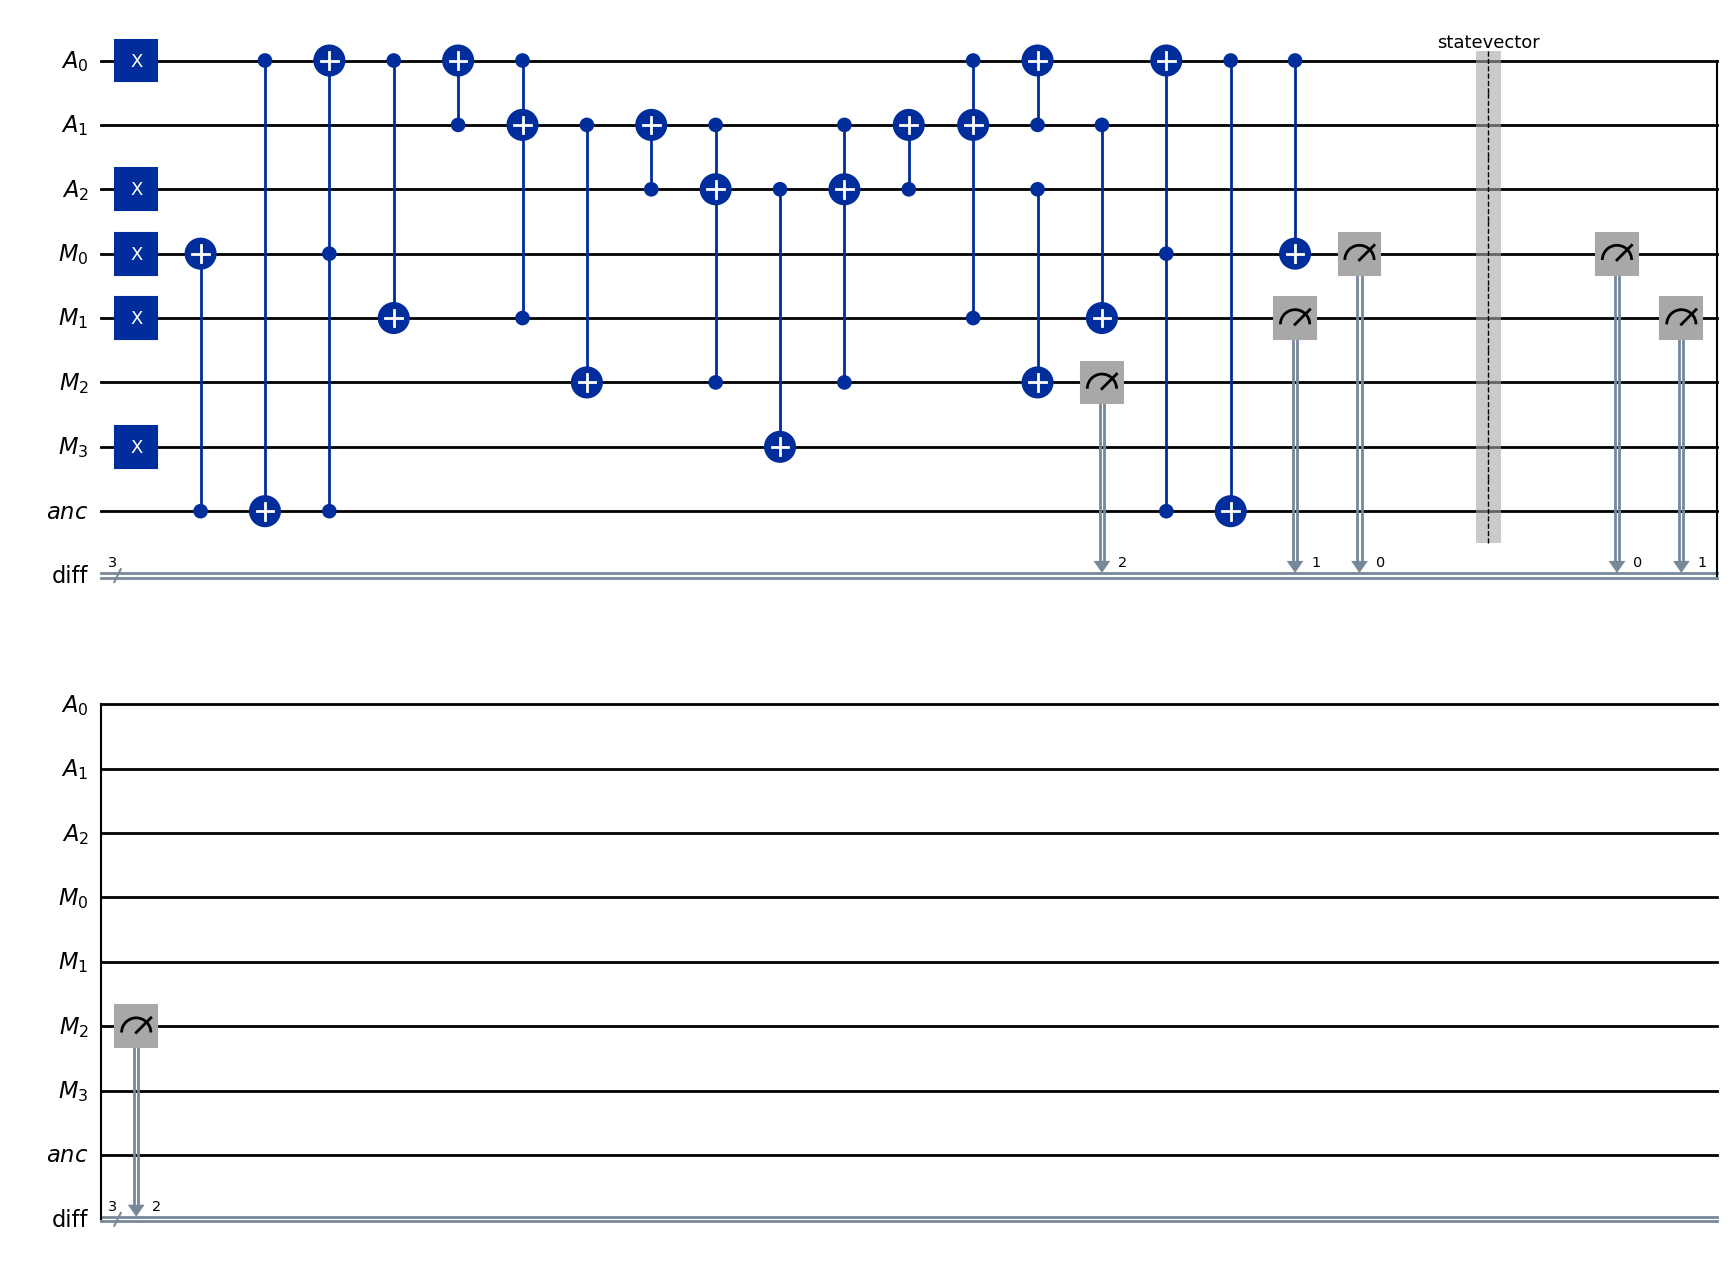

In [30]:
qc.draw("mpl")

Division

In [37]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, AncillaRegister
from qiskit.circuit.library import CDKMRippleCarryAdder

def load_int(qc, reg, value, bits=None):
    if bits is None:
        bits = len(reg)
    for i in range(bits):
        if (value >> i) & 1:
            qc.x(reg[i])

def make_unsigned_division_circuit(n, A_val=None, B_val=None):
    # A: dividend (n)
    A = QuantumRegister(n, 'A')
    # B: divisor (n)   <-- IMPORTANT: n, not n+1
    B = QuantumRegister(n, 'B')
    # R: remainder (n+1) to hold borrow/carry
    R = QuantumRegister(n + 1, 'R')
    # Q: quotient (n)
    Q = QuantumRegister(n, 'Q')

    adder = CDKMRippleCarryAdder(n, kind='half')  # <-- IMPORTANT: size n
    anc = AncillaRegister(adder.num_ancillas, 'anc')

    cQ = ClassicalRegister(n, 'cQ')
    cR = ClassicalRegister(n + 1, 'cR')

    qc = QuantumCircuit(A, B, R, Q, anc, cQ, cR)

    # Load optional classical inputs
    if A_val is not None:
        load_int(qc, A, A_val, bits=n)
    if B_val is not None:
        load_int(qc, B, B_val, bits=n)

    SUB = adder.inverse().to_gate(label="SUB")  # R := R - B  (because inverse add)
    ADD = adder.to_gate(label="ADD")            # R := R + B

    # qargs must match the adder’s expected order: (first n) + (second n+1) + anc
    qargs = list(B) + list(R) + list(anc)

    for i in reversed(range(n)):
        # Shift-left R by 1
        for j in reversed(range(1, n + 1)):
            qc.swap(R[j], R[j - 1])

        # Bring next dividend bit into R[0]
        qc.swap(R[0], A[i])

        # R = R - B
        qc.append(SUB, qargs)

        # Underflow flag = MSB of R (R[n]) after subtraction
        # Save underflow into Q[i]
        qc.cx(R[n], Q[i])

        # If underflow, restore: R = R + B (controlled on Q[i])
        cADD = ADD.control(1)
        qc.append(cADD, [Q[i]] + qargs)

        # Quotient bit is 1 if NOT underflow
        qc.x(Q[i])

    qc.measure(Q, cQ)
    qc.measure(R, cR)
    return qc

# Example: 11 / 5 with n=4 -> Q=2, R=1
qc = make_unsigned_division_circuit(n=4, A_val=12, B_val=2)

In [38]:
from qiskit_aer import Aer
from qiskit import transpile

backend = Aer.get_backend("aer_simulator")
tqc = transpile(qc, backend)
result = backend.run(tqc, shots=1024).result()
counts = result.get_counts()
print(counts)

{'00000 0110': 1024}


In [39]:
bitstring = next(iter(counts))
rem_bits, quo_bits = bitstring.split()

remainder = int(rem_bits, 2)
quotient = int(quo_bits, 2)

print("Quotient:", quotient)
print("Remainder:", remainder)

Quotient: 6
Remainder: 0


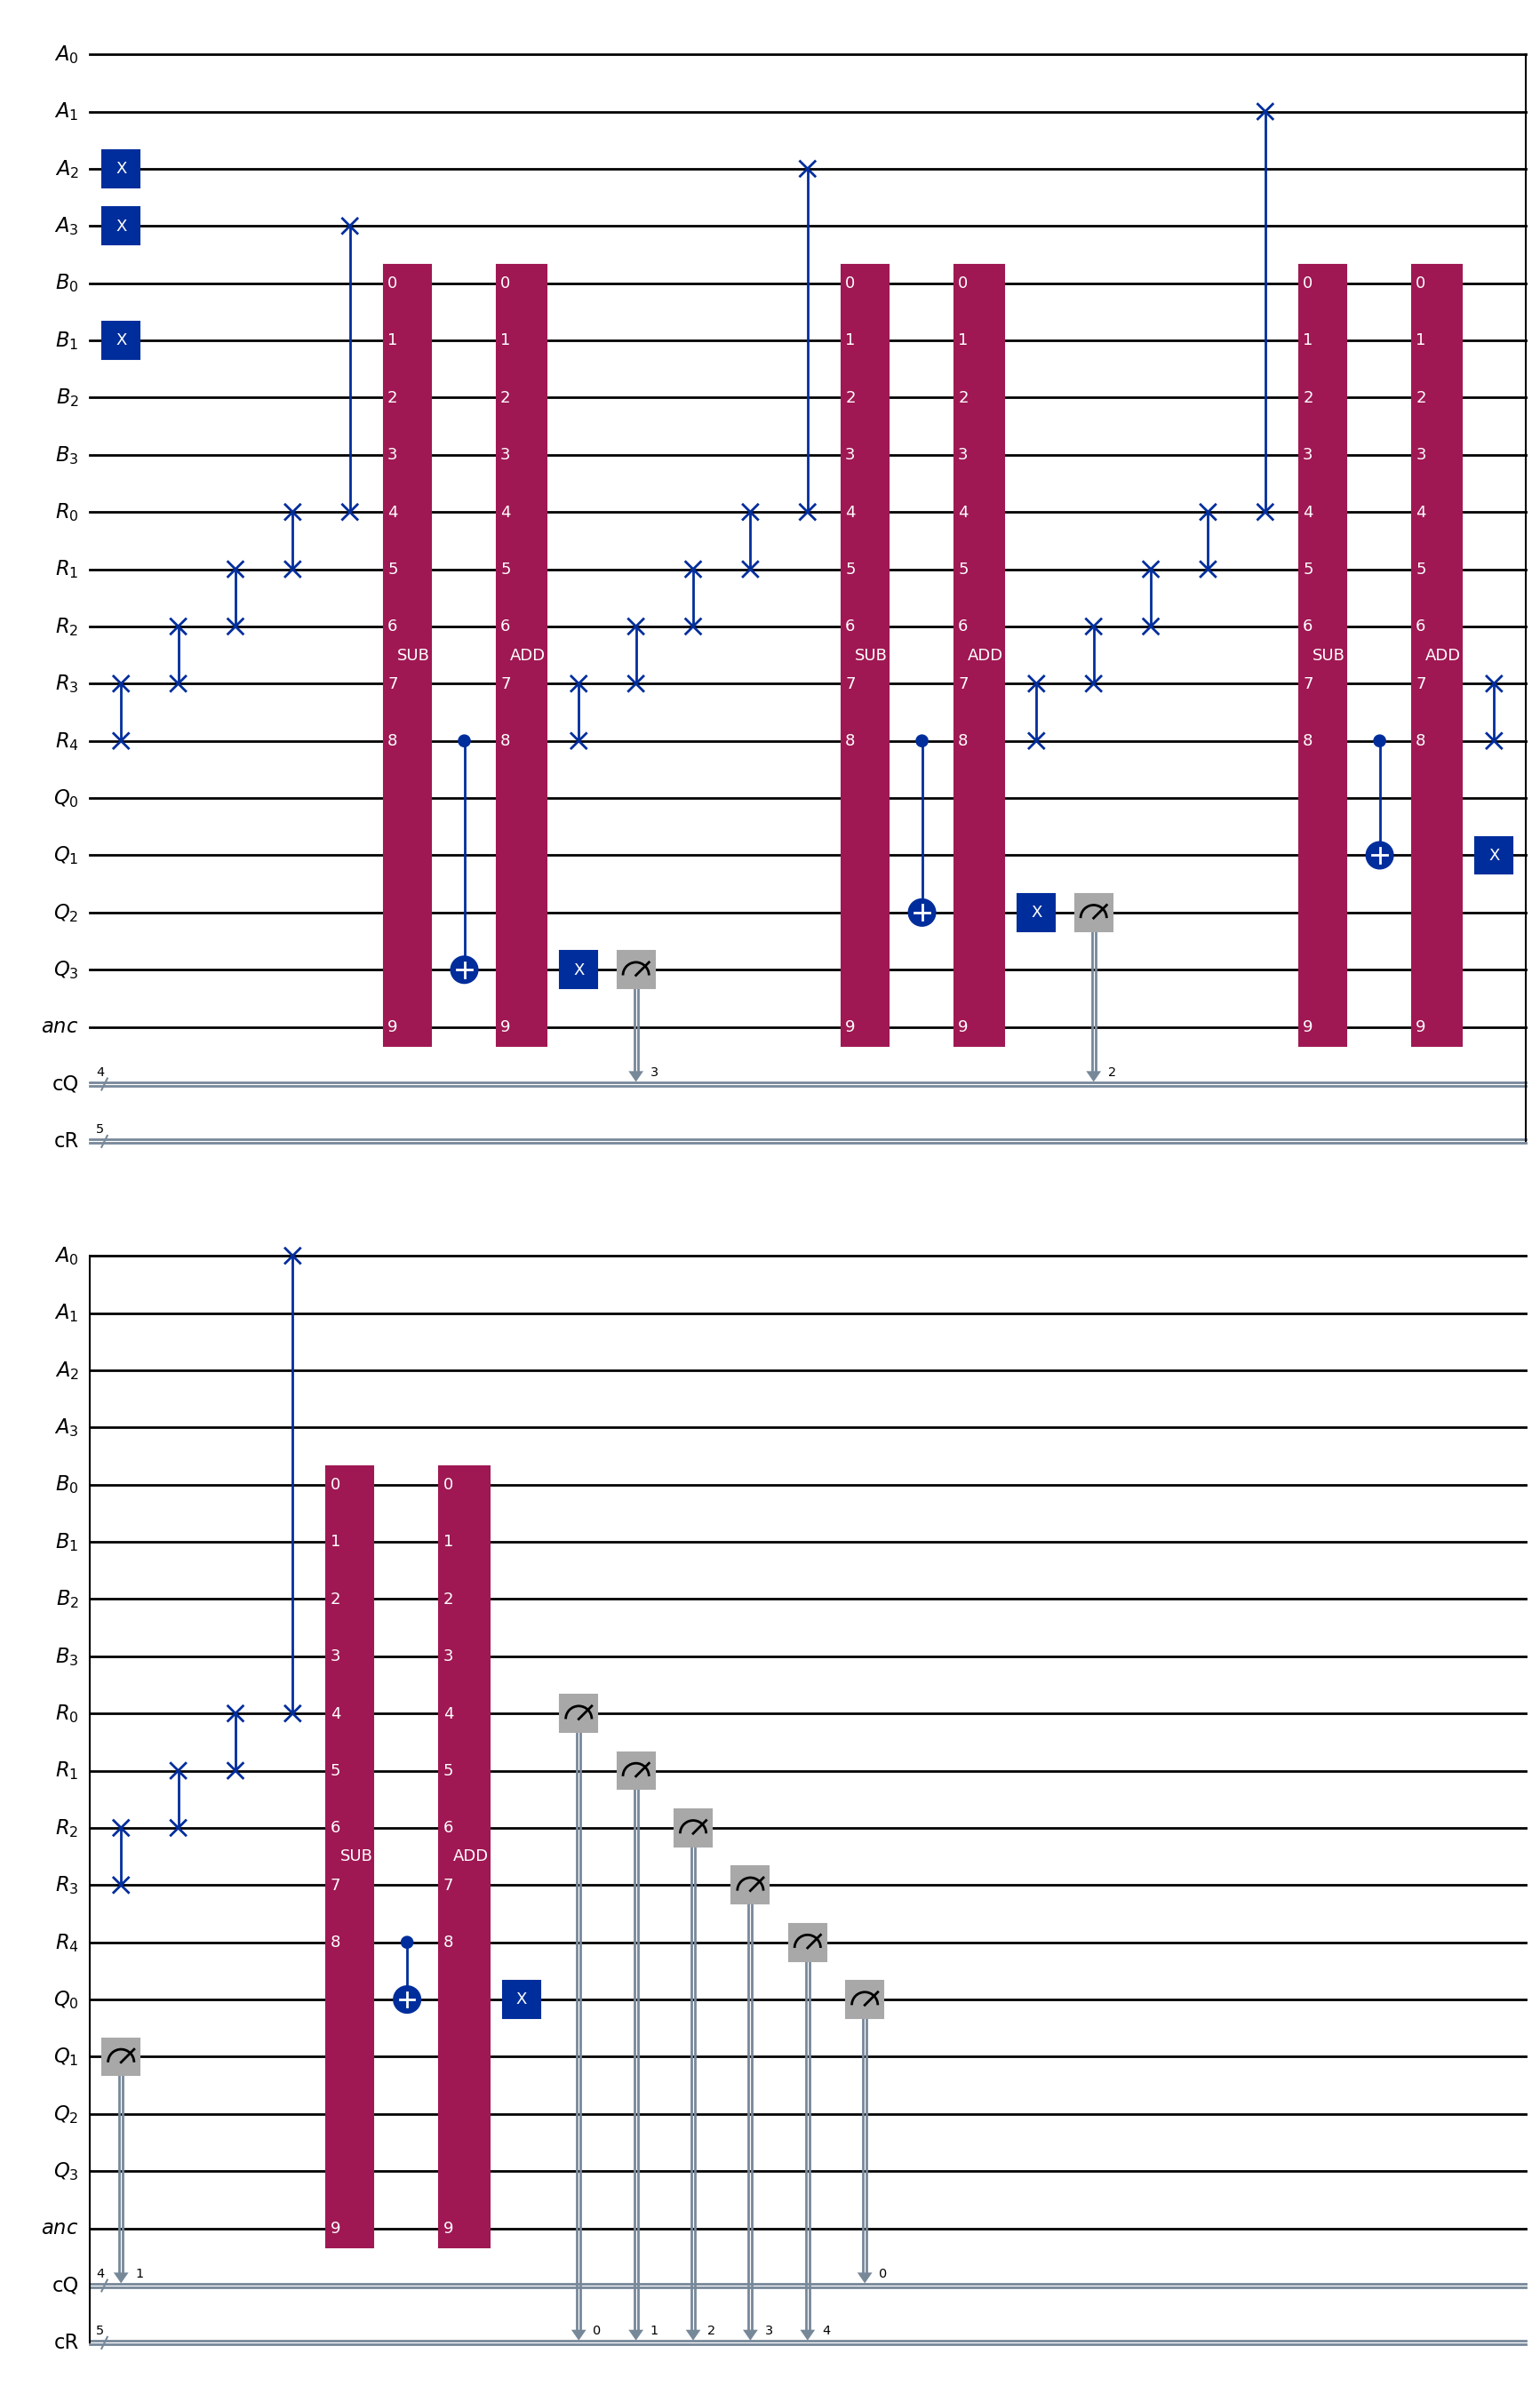

In [40]:
qc.draw("mpl")